In [42]:
#Day8_YOLO_vs_HSV_Ball_Detection.ipynb

In [43]:
!pip install -q ultralytics

In [44]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage

In [45]:
results = model.predict(source="/content/Ney_ball.jpg", conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))


image 1/1 /content/Ney_ball.jpg: 640x448 2 persons, 1 sports ball, 158.0ms
Speed: 8.0ms preprocess, 158.0ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 448)
class id: 32 confidence: 0.9579882621765137
class id: 0 confidence: 0.8609246015548706
class id: 0 confidence: 0.6779241561889648


In [46]:
results = model.predict(source="/content/sadio_ball.jpg", conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))


image 1/1 /content/sadio_ball.jpg: 448x640 2 persons, 1 sports ball, 151.2ms
Speed: 3.8ms preprocess, 151.2ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
class id: 32 confidence: 0.7753517627716064
class id: 0 confidence: 0.6816096305847168
class id: 0 confidence: 0.5597273707389832


In [47]:
results = model.predict(source="/content/random_ball.jpg", conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))


image 1/1 /content/random_ball.jpg: 640x448 1 person, 153.7ms
Speed: 3.3ms preprocess, 153.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 448)
class id: 0 confidence: 0.8277583122253418


In [48]:
results = model.predict(source="/content/girl_ball.jpg", conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))


image 1/1 /content/girl_ball.jpg: 640x448 1 person, 1 sports ball, 166.9ms
Speed: 3.0ms preprocess, 166.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 448)
class id: 0 confidence: 0.9012978672981262
class id: 32 confidence: 0.4405207335948944


In [49]:
results = model.predict(source="/content/Ronaldo_ball.jpg", conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))


image 1/1 /content/Ronaldo_ball.jpg: 640x384 1 person, 1 sports ball, 133.2ms
Speed: 5.8ms preprocess, 133.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)
class id: 32 confidence: 0.8320321440696716
class id: 0 confidence: 0.6828271150588989


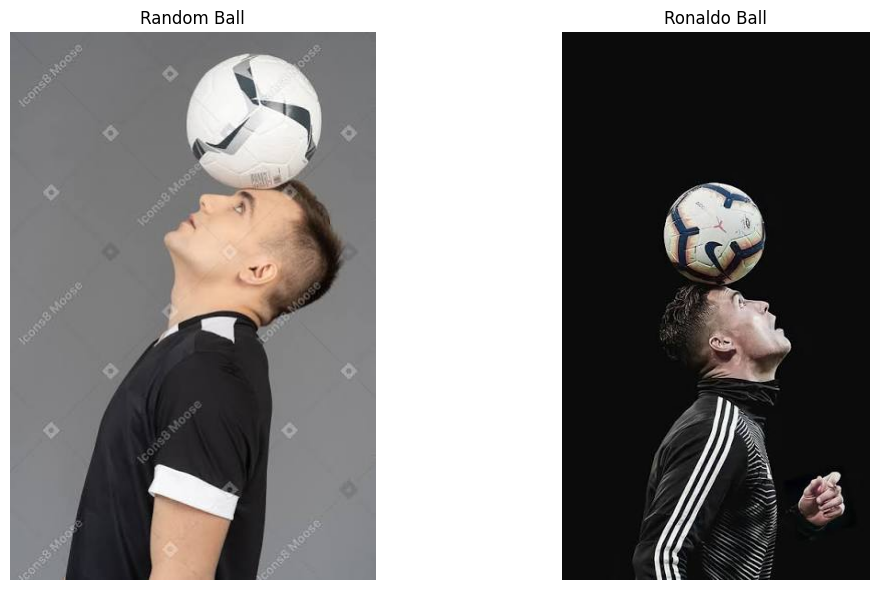

In [50]:
import matplotlib.pyplot as plt
from PIL import Image

img1 = Image.open('/content/random_ball.jpg')
img2 = Image.open('/content/Ronaldo_ball.jpg')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img1)
axes[0].set_title('Random Ball')
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title('Ronaldo Ball')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [51]:
from PIL import Image, ImageEnhance

img = Image.open('/content/random_ball.jpg')

# Boost contrast
enhancer = ImageEnhance.Contrast(img)
img_contrast = enhancer.enhance(1.8)   # try 1.5-2.5 if needed

img_contrast.save('/content/random_ball_contrast.jpg')

# Rerun YOLO on the enhanced version
results = model.predict(source='/content/random_ball_contrast.jpg', conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))


image 1/1 /content/random_ball_contrast.jpg: 640x448 1 person, 160.8ms
Speed: 4.0ms preprocess, 160.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)
class id: 0 confidence: 0.7900233268737793


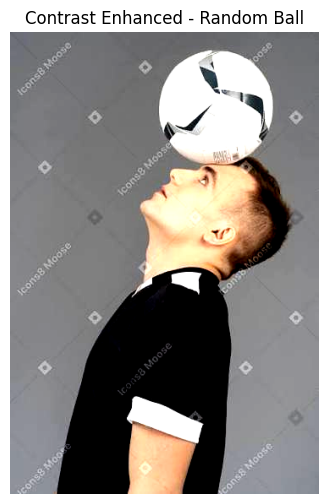

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(img_contrast)
plt.title('Contrast Enhanced - Random Ball')
plt.axis('off')
plt.show()

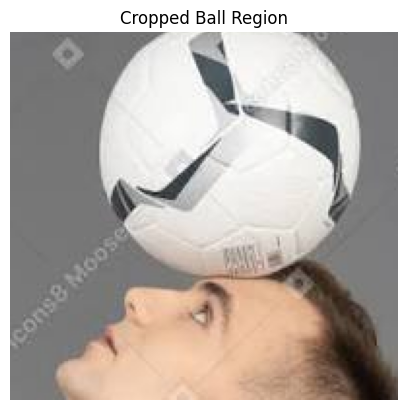


image 1/1 /content/random_ball1.jpg: 544x640 1 person, 207.1ms
Speed: 3.9ms preprocess, 207.1ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)
class id: 0 confidence: 0.3430490493774414


In [53]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/random_ball1.jpg')

# # crop tightly around just the ball region (adjust coordinates by eye)
# # format: left, top, right, bottom
# ball_crop = img.crop((130, 30, 330, 220))  # tweak these numbers based on what you see

# ball_crop.save('/content/random_ball_cropped.jpg')

plt.figure(figsize=(5,5))
plt.imshow(ball_crop)
plt.axis('off')
plt.title('Cropped Ball Region')
plt.show()



results = model.predict(source='/content/random_ball1.jpg', conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))

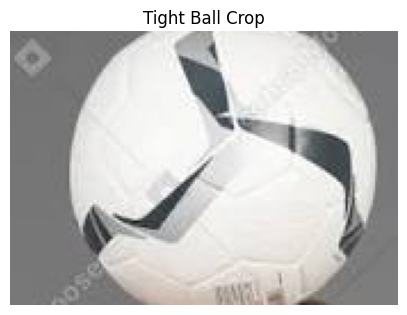


image 1/1 /content/random_ball_tight.jpg: 480x640 1 person, 161.2ms
Speed: 3.4ms preprocess, 161.2ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
class id: 0 confidence: 0.6301351189613342


In [54]:
img = Image.open('/content/random_ball.jpg')

# tighten this — only the ball, cut off most of the head/face
ball_crop_tight = img.crop((150, 30, 320, 150))  # adjust based on what you see

ball_crop_tight.save('/content/random_ball_tight.jpg')

plt.figure(figsize=(5,5))
plt.imshow(ball_crop_tight)
plt.axis('off')
plt.title('Tight Ball Crop')
plt.show()

results = model.predict(source='/content/random_ball_tight.jpg', conf=0.3)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))

In [55]:
model_s = YOLO("yolov8s.pt")   # downloads automatically first time

results_s = model_s.predict(source='/content/random_ball_tight.jpg', conf=0.3)

for box in results_s[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))


image 1/1 /content/random_ball_tight.jpg: 480x640 1 person, 463.4ms
Speed: 4.5ms preprocess, 463.4ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
class id: 0 confidence: 0.7186472415924072


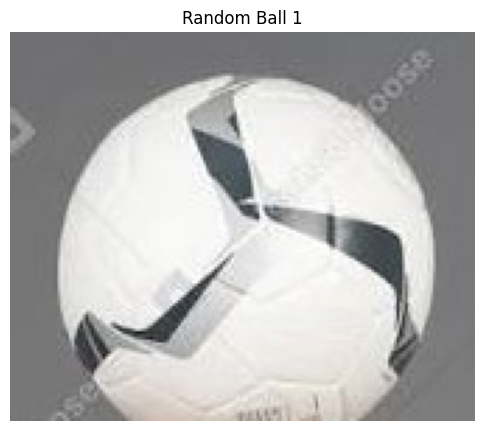


image 1/1 /content/random_ball1.jpg: 544x640 1 person, 192.1ms
Speed: 5.5ms preprocess, 192.1ms inference, 1.1ms postprocess per image at shape (1, 3, 544, 640)
class id: 0 confidence: 0.3430490493774414


In [56]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('/content/random_ball1.jpg')

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title('Random Ball 1')
plt.show()

results = model.predict(source='/content/random_ball1.jpg', conf=0.1)

for box in results[0].boxes:
    print("class id:", int(box.cls[0]), "confidence:", float(box.conf[0]))

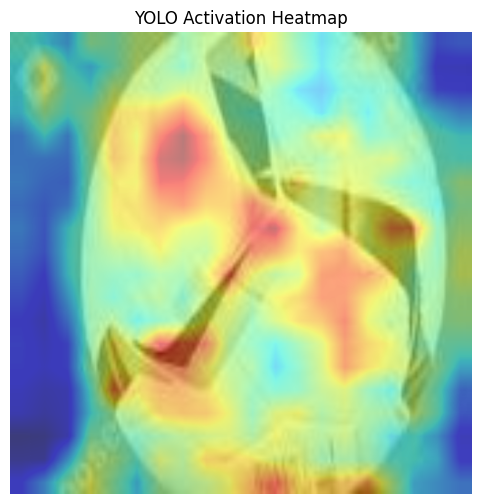

In [57]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/random_ball_tight.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (640, 640))
img_tensor = torch.from_numpy(img_resized).permute(2,0,1).unsqueeze(0).float() / 255

# hook into an intermediate layer to grab its activation
activation = {}
def hook(module, input, output):
    activation['feat'] = output

layer = model.model.model[9]  # try 9, adjust if needed
handle = layer.register_forward_hook(hook)

with torch.no_grad():
    model.model(img_tensor)

handle.remove()

feat = activation['feat'][0].mean(dim=0).numpy()  # average across channels
feat = cv2.resize(feat, (640, 640))
feat = (feat - feat.min()) / (feat.max() - feat.min())

plt.figure(figsize=(6,6))
plt.imshow(img_resized)
plt.imshow(feat, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title('YOLO Activation Heatmap')
plt.show()

In [ ]:
# Day 8 Conclusion:
# Compared pretrained YOLOv8 against HSV color-based detection on the same
# football images. YOLO worked well on standard gameplay photos (confidence 0.77–0.96)
# but failed on an isolated studio-style ball image, misclassifying it as "person"
#  — even after cropping out all human features. The same failure happened with
# both YOLOv8n and YOLOv8s, ruling out model size as the cause. This points to a
# real domain gap: COCO's "sports ball" class is trained on balls in gameplay
# context, not clean isolated product shots, so it doesn't generalize to this ball's
# specific pattern. HSV succeeded here because it only checks color, not
# learned shapes — but HSV fails elsewhere (crowd colors matching ball).
# Neither method alone is production-ready. Next step: fine-tune YOLO on a
# football-specific dataset, or build a hybrid pipeline that falls back to
# HSV when YOLO confidence is low.